### 在线学习平台用户行为分析（业务指标版）
**分析目的**：评估用户活跃度、粘性、学习深度、功能渗透率及流失风险，为运营策略提供数据持。

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
 
# 1. 数据加载与预处理
df = pd.read_csv('ed38976-edd.csv')

# 清洗：time_watched 不能超过 video_duration
df['time_watched'] = np.minimum(df['time_watched'], df['video_duration'])

# 计算观看完成率
df['watch_completion_rate'] = df['time_watched'] / df['video_duration']
# 新特征  disengagement_score 脱离度分数（数值，范围0～1，越高表示学习投入度越低，如0.12、0.6）
df['high_disengagement'] = (df['disengagement_score'] > 0.6).astype(int) #将布尔值转换为整数：True → 1，False → 0。

print("数据概览：", df.shape)
print("\n缺失值：\n", df.isnull().sum())



数据概览： (14101, 23)

缺失值：
 student_id               226
name                     196
age                      202
experience_level         186
learning_style           194
interests                186
course_id                177
course_name              200
category                 203
difficulty_level         213
ratings                  217
num_reviews              197
time_spent_on_course     193
completion_status        210
video_id                 198
video_topic              193
video_duration           193
time_watched             353
skip_count               217
pause_count              217
disengagement_score      209
watch_completion_rate    353
high_disengagement         0
dtype: int64


In [2]:
# 处理缺失数据输出
# 定义关键字段列表
key_cols = ['student_id', 'course_id', 'category', 'experience_level', 
            'time_watched', 'disengagement_score']

# 删除关键字段缺失的行
df_clean = df.dropna(subset=key_cols)

print(f"原始记录数：{len(df)}")
print(f"删除关键字段缺失后剩余：{len(df_clean)}")
print(f"删除比例：{(1 - len(df_clean)/len(df)):.1%}")

# 对于非关键字段（如 age, ratings, num_reviews），若仍有缺失，可以填充中位数
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['ratings'] = df_clean['ratings'].fillna(df_clean['ratings'].median())
df_clean['num_reviews'] = df_clean['num_reviews'].fillna(0)  # 无评论可填0

# 然后重新计算 watch_completion_rate 和 high_disengagement（此时无缺失）
df_clean['watch_completion_rate'] = df_clean['time_watched'] / df_clean['video_duration']
df_clean['high_disengagement'] = (df_clean['disengagement_score'] > 0.6).astype(int)

# 可选：删除其他仍有缺失的行（如果剩余缺失很少）
df_clean = df_clean.dropna()

# 保存清洗后数据
df_clean.to_csv('learning_data_cleaned.csv', index=False)
print("\n清洗后数据已保存为 learning_data_cleaned.csv")

# 查看清洗后数据
df_clean.isnull().sum()

原始记录数：14101
删除关键字段缺失后剩余：12983
删除比例：7.9%

清洗后数据已保存为 learning_data_cleaned.csv


student_id               0
name                     0
age                      0
experience_level         0
learning_style           0
interests                0
course_id                0
course_name              0
category                 0
difficulty_level         0
ratings                  0
num_reviews              0
time_spent_on_course     0
completion_status        0
video_id                 0
video_topic              0
video_duration           0
time_watched             0
skip_count               0
pause_count              0
disengagement_score      0
watch_completion_rate    0
high_disengagement       0
dtype: int64

### 导入清洗后数据

In [3]:
# 导入清洗后数据
df = pd.read_csv('learning_data_cleaned.csv')
print(f"清洗后记录数：{len(df)}")

清洗后记录数：12108


=== 用户活跃度统计 ===
       courses_cnt   videos_cnt  time_spent_on_course  completion_status
count  3920.000000  3920.000000           3920.000000        3920.000000
mean      3.087500     3.088776            311.463136           0.394470
std       1.657061     1.655838            110.946782           0.329942
min       1.000000     1.000000             30.000000           0.000000
25%       2.000000     2.000000            238.000000           0.000000
50%       3.000000     3.000000            312.708333           0.333333
75%       4.000000     4.000000            382.333333           0.600000
max      11.000000    11.000000            599.000000           1.000000

=== 不同经验水平用户活跃度 ===
          user_cnt  completion_status  time_spent_on_course  \
count     4.000000           4.000000              4.000000   
mean   1922.250000           0.438459            267.642685   
std    1262.572605           0.094857             95.454965   
min      29.000000           0.387497            124.5

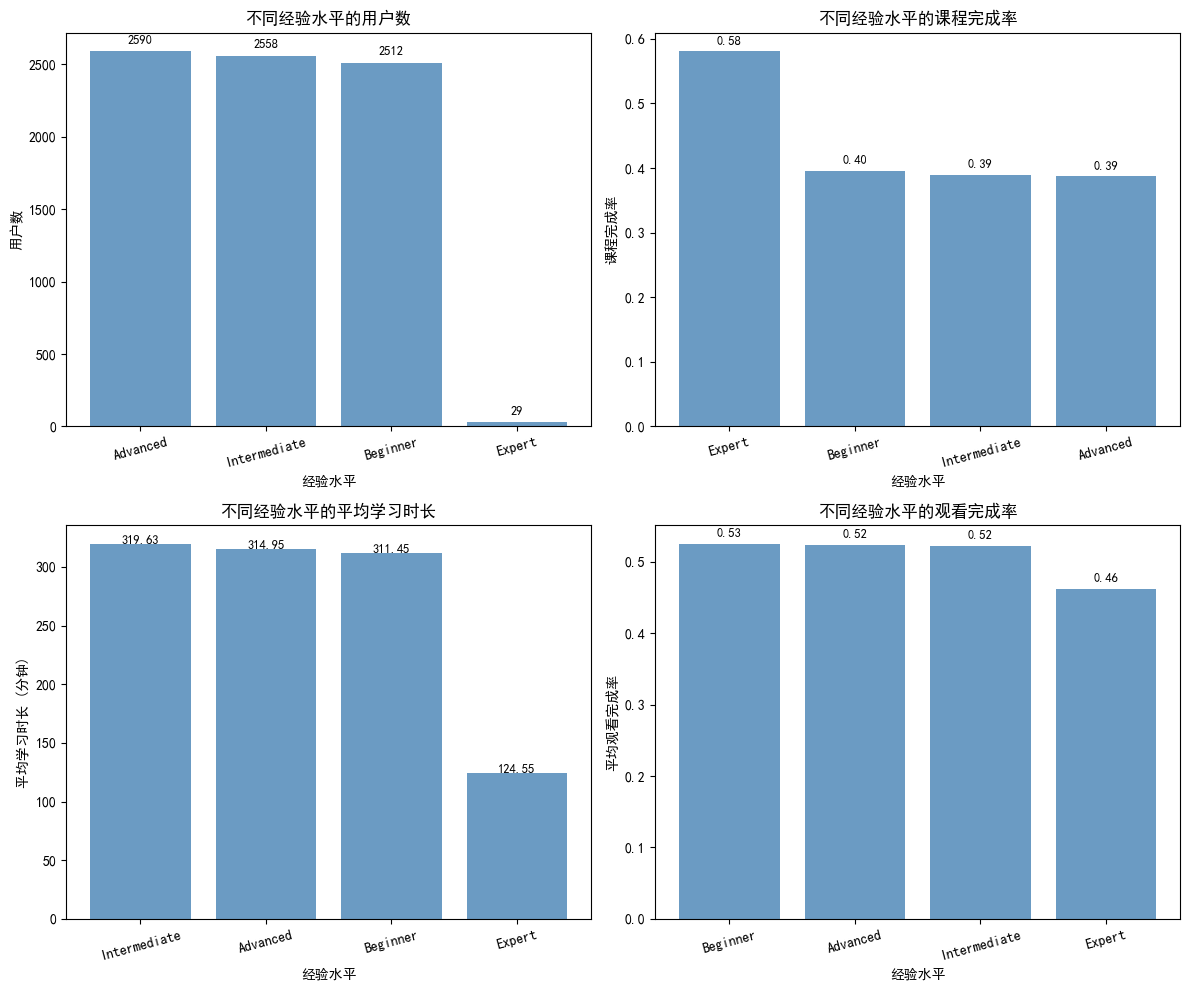

In [5]:
# 2. 用户活跃度（整体 & 分群）
user_activity = df.groupby('student_id').agg({
    'course_id': 'nunique',           # 学习课程数
    'video_id': 'count',               # 观看视频数 (一个视频看两遍算两次，属于行为次数，不去重)
    'time_spent_on_course': 'mean',   # 平均每课程学习时长
    'completion_status': 'mean'       # 课程完成率 true(1)的比率
}).rename(columns={'course_id': 'courses_cnt', 'video_id': 'videos_cnt'})

print("=== 用户活跃度统计 ===")
print(user_activity.describe())

exp_activity = df.groupby('experience_level').agg({
    'student_id': 'nunique',
    'completion_status': 'mean',  
    'time_spent_on_course': 'mean',
    'watch_completion_rate': 'mean'
}).rename(columns={'student_id': 'user_cnt'})
print("\n=== 不同经验水平用户活跃度 ===")
print(exp_activity.describe())


# 绘制不同经验水平用户活跃度对比图
# 创建子图布局：2行2列
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # 扁平化便于索引

# 定义要绘制的指标及其对应的Y轴标签
metrics = [
    ('user_cnt', '用户数', '不同经验水平的用户数'),
    ('completion_status', '课程完成率', '不同经验水平的课程完成率'),
    ('time_spent_on_course', '平均学习时长 (分钟)', '不同经验水平的平均学习时长'),
    ('watch_completion_rate', '平均观看完成率', '不同经验水平的观看完成率')
]

for i, (col, ylabel, title) in enumerate(metrics):
    # 按指标值降序排序（让最高的排在最前面）
    data = exp_activity[col].sort_values(ascending=False)
    axes[i].bar(data.index, data.values, color='steelblue', alpha=0.8)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('经验水平')
    axes[i].tick_params(axis='x', rotation=15)
    # 在柱顶添加数值标签
    for j, v in enumerate(data.values):
        axes[i].text(j, v + (0.01 if col != 'user_cnt' else max(data.values)*0.02), 
                     f'{v:.2f}' if col != 'user_cnt' else f'{int(v)}', 
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# 3. 用户粘性代理指标（高完成率 + 高观看完成率）
user_watch_rate = df.groupby('student_id')['watch_completion_rate'].mean().reset_index()
user_completion = df.groupby('student_id')['completion_status'].mean().reset_index()
sticky_users = (user_completion["completion_status"] > 0) & (user_watch_rate["watch_completion_rate"] > 0.8)
sticky_ratio = sticky_users.sum() / len(user_completion)
print(f"\n每个学生的平均观看完成率：{user_watch_rate}")
print(f"\n每个学生的课程完成率：{user_completion}")
print(f"\n高粘性用户占比（至少完成一门课 + 平均观看完成率>80%）：{sticky_ratio:.2%}")



每个学生的平均观看完成率：                                student_id  watch_completion_rate
0     000f4068-2ac7-4ce3-894e-667f3471d6cc               0.773296
1     001cf722-f94b-41d4-a26b-c6c0e9b8d71c               0.220708
2     00283588-7331-44c1-a511-67c2e077d5c6               0.125000
3     002ded84-7e2a-4565-8c11-96f135455247               0.089286
4     00404de1-3625-4f34-86b5-5703d2c7bf5f               0.934072
...                                    ...                    ...
3915  ff8da7da-7eed-43ec-8066-06c85427464c               0.610603
3916  ff9fb0e6-d1eb-4e21-ac90-b89f2b1dc9da               0.651276
3917  ffaff88a-cb6e-4385-b973-80a85273f7e4               0.268542
3918  ffc77721-898a-4127-a42d-da8cc30cbbb2               0.458650
3919  ffffdd57-e84a-405b-8707-111c20973185               0.352304

[3920 rows x 2 columns]

每个学生的课程完成率：                                student_id  completion_status
0     000f4068-2ac7-4ce3-894e-667f3471d6cc           1.000000
1     001cf722-f94b-41d4-a26b-c6c

业务含义：粘性用户是平台的忠实学习者，提升这部分比例能带动长期留存。


平均每用户每课程学习时长：314.9 分钟，中位数：316.0 分钟

各课程类别观看完成率：
category
Web Development    0.532530
Data Science       0.523927
Cloud Computing    0.522355
Cybersecurity      0.522068
AI                 0.517187
Blockchain         0.486997
Name: watch_completion_rate, dtype: float64


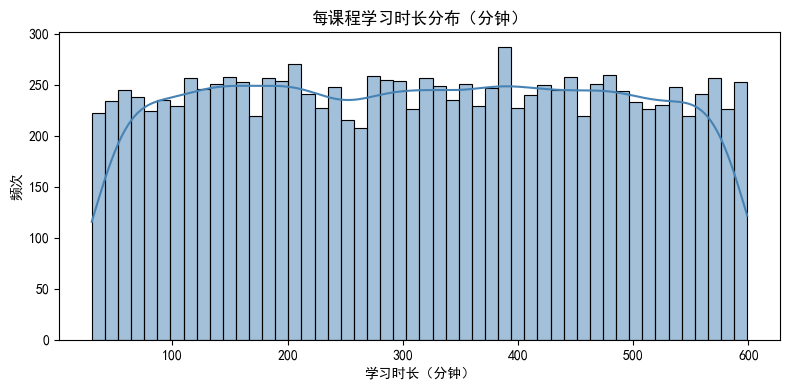

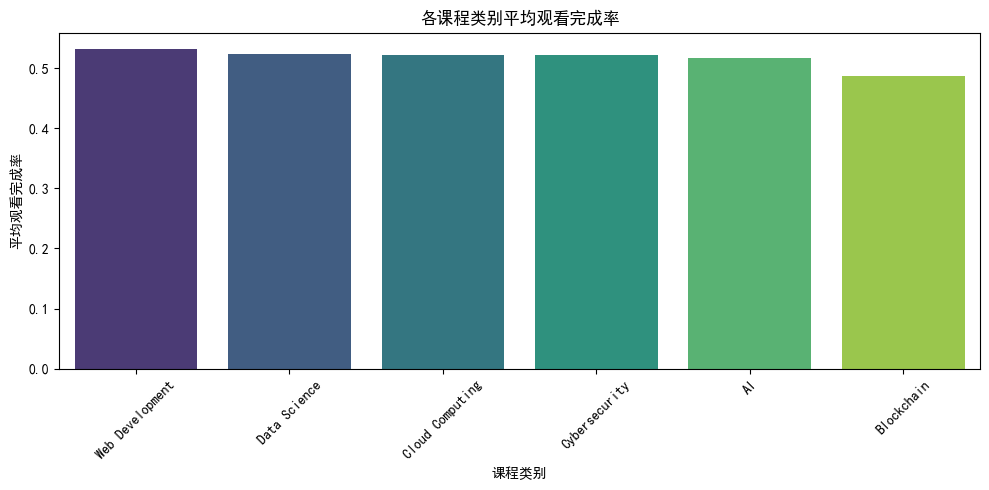

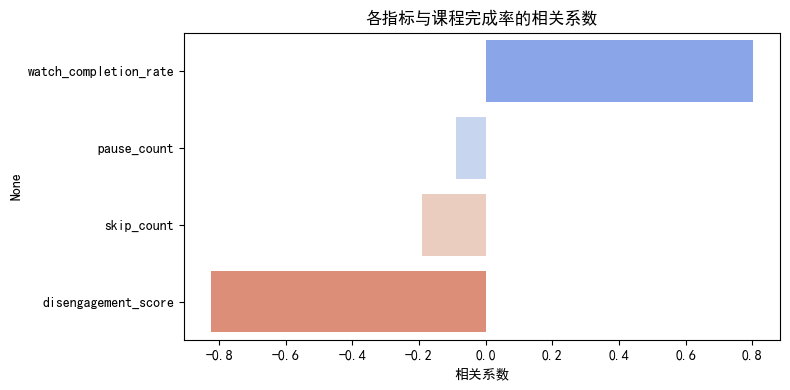

In [7]:
# 4. 使用时长分析
avg_time = df['time_spent_on_course'].mean()
med_time = df['time_spent_on_course'].median()
print(f"\n平均每用户每课程学习时长：{avg_time:.1f} 分钟，中位数：{med_time:.1f} 分钟")

# 课程类别观看完成率对比
category_watch = df.groupby('category')['watch_completion_rate'].mean().sort_values(ascending=False)
print("\n各课程类别观看完成率：")
print(category_watch)


# # 可视化：时长分布 + 类别完成率
# ========== 图表1：每课程学习时长分布 ==========
plt.figure(figsize=(8, 4))
sns.histplot(df['time_spent_on_course'], bins=50, kde=True, color='steelblue')
plt.title('每课程学习时长分布（分钟）')
plt.xlabel('学习时长（分钟）')
plt.ylabel('频次')
plt.tight_layout()
plt.show()

# ========== 图表2：各课程类别观看完成率 ==========
plt.figure(figsize=(10, 5))
sns.barplot(x=category_watch.index, y=category_watch.values, palette='viridis')
plt.title('各课程类别平均观看完成率')
plt.xlabel('课程类别')
plt.ylabel('平均观看完成率')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== 图表3：各指标与课程完成率的相关系数 ==========

# 选取需要分析的数值列
corr_cols = ['watch_completion_rate', 'disengagement_score', 
             'skip_count', 'pause_count', 'completion_status']
corr_df = df[corr_cols].copy()
# 计算相关系数矩阵（默认使用皮尔逊相关系数）
corr_matrix = corr_df.corr()
# 提取与 completion_status 的相关系数（去掉自身）
corr_with_completion = corr_matrix['completion_status'].drop('completion_status').sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=corr_with_completion.values, y=corr_with_completion.index, palette='coolwarm')
plt.title('各指标与课程完成率的相关系数')
plt.xlabel('相关系数')
plt.tight_layout()
plt.show()


In [8]:
# 5. 功能渗透率（跳过/暂停）
total_users = df['student_id'].nunique()
skip_users = df[df['skip_count'] > 0]['student_id'].nunique()
pause_users = df[df['pause_count'] > 0]['student_id'].nunique()
print(f"\n功能渗透率：")
print(f"  使用跳过功能的用户占比：{skip_users/total_users:.2%}")
print(f"  使用暂停功能的用户占比：{pause_users/total_users:.2%}")

# 按经验水平分析跳过行为
exp_skip = df.groupby('experience_level')['skip_count'].mean().sort_values(ascending=False)
print("\n各经验水平平均跳过次数：")
print(exp_skip)




功能渗透率：
  使用跳过功能的用户占比：96.81%
  使用暂停功能的用户占比：97.35%

各经验水平平均跳过次数：
experience_level
Intermediate    4.547519
Advanced        4.481635
Beginner        4.462324
Expert          0.451613
Name: skip_count, dtype: float64



高风险流失用户占比：9.13%

风险用户典型特征（众数）：
experience_level    Intermediate
learning_style            Visual
age                         23.0
Name: 0, dtype: object

风险用户课程类别分布：
category
Cloud Computing    0.232653
Data Science       0.204082
AI                 0.198639
Cybersecurity      0.185034
Web Development    0.175510
Blockchain         0.004082
Name: proportion, dtype: float64


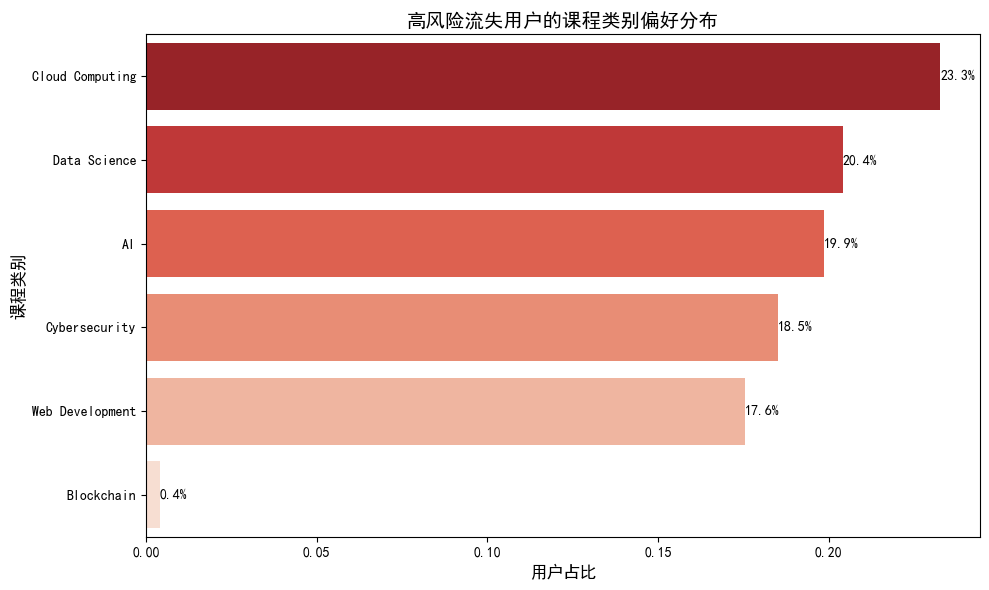

In [9]:
# 6. 流失预警（低投入高风险用户定义）
# 条件：未完成任何课程 + 观看完成率 < 0.3 + 脱离度 > 0.6
risk_students = df.groupby('student_id').filter(
    lambda x: (x['completion_status'].sum() == 0) &
              (x['watch_completion_rate'].mean() < 0.3) &
              (x['disengagement_score'].mean() > 0.6)
)['student_id'].unique()
risk_ratio = len(risk_students) / total_users
print(f"\n高风险流失用户占比：{risk_ratio:.2%}")

# 风险用户画像
risk_df = df[df['student_id'].isin(risk_students)]
print("\n风险用户典型特征（众数）：")
print(risk_df[['experience_level', 'learning_style', 'age']].mode().iloc[0])

# 风险用户课程类别偏好
risk_category = risk_df['category'].value_counts(normalize=True)
print("\n风险用户课程类别分布：")
print(risk_category)

plt.figure(figsize=(10, 6))
# 水平条形图，按占比降序排列
sns.barplot(x=risk_category.values, y=risk_category.index, palette='Reds_r')
plt.title('高风险流失用户的课程类别偏好分布', fontsize=14)
plt.xlabel('用户占比', fontsize=12)
plt.ylabel('课程类别', fontsize=12)
for i, (cat, val) in enumerate(risk_category.items()):
    plt.text(val , i, f'{val:.1%}', va='center')
plt.tight_layout()
plt.show()
